In [165]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import requests as rq
from bs4 import BeautifulSoup as bs

#Información adicional

Se desea obtener el tipo de cambio de real de dolar para el analisis a $ argentinos. Para ello se realizará un Web Scraping.

In [245]:
url= "https://dolarhoy.com/cotizaciondolarbolsa"
response = rq.get(url)
print (response)

<Response [200]>


In [246]:
soup=bs(response.text,"html.parser")

In [247]:
#Buscar nombres y crear listas
buscar_nombres = soup.find_all('div', class_="title")
nombres = []
precios = []

In [248]:
#Obtener el nombre de las cotizaciones de la página
for elemento in buscar_nombres:
    nombres.append(elemento.get_text())

In [249]:
#Obtener las cotizaciones de la página
buscar_cotiz = soup.find_all('div', class_="venta")
for elemento in buscar_cotiz:
    precios.append(elemento.get_text())

In [250]:
#Revisión de calidad
print (nombres,precios)
print("Longitud de nombres:", len(nombres))
print("Longitud de precios:", len(precios))

['Dólar MEP/Bolsa', 'Entidad', 'Dólar Libre', 'Dólar Mayorista', 'Dólar MEP/Bolsa', 'Contado con liqui', 'Moneda', 'Euro', 'Real brasileño', 'Peso uruguayo', 'Peso chileno'] ['Venta', '1050,00', '1032,93', '1049,90', '1072,50', 'Venta', '1029,77', '171,17', '23,18', '100,71']
Longitud de nombres: 11
Longitud de precios: 10


In [251]:
#Ajustes
del nombres[0]

print("Longitud de nombres:", len(nombres))
print("Longitud de precios:", len(precios))

Longitud de nombres: 10
Longitud de precios: 10


In [252]:
dfcotiz= pd.DataFrame ({"Moneda": nombres,"Precio": precios})

In [253]:
dfcotiz
#eliminar la primera fila no muestra información relevante

,Moneda,Precio
0,Entidad,Venta
1,Dólar Libre,"1050,00"
2,Dólar Mayorista,"1032,93"
3,Dólar MEP/Bolsa,"1049,90"
4,Contado con liqui,"1072,50"
5,Moneda,Venta
6,Euro,"1029,77"
7,Real brasileño,"171,17"
8,Peso uruguayo,"23,18"
9,Peso chileno,"100,71"


In [264]:
#DF con el tipo de cambio deseado

TCambio=dfcotiz.drop([0, 5]).reset_index(drop=True)
TCambio["Precio"] = TCambio["Precio"].str.replace(",", ".").astype(float)
TCambio

,Moneda,Precio
0,Dólar Libre,1050.00
1,Dólar Mayorista,1032.93
2,Dólar MEP/Bolsa,1049.90
3,Contado con liqui,1072.50
4,Euro,1029.77
5,Real brasileño,171.17
6,Peso uruguayo,23.18
7,Peso chileno,100.71


# Analisis de información del cliente (Importación y EDA)

In [80]:
df = pd.read_excel('data.comida.xlsx')

In [81]:
df.shape

(3297, 24)

In [82]:
df.head(10)

,OrderID,ShipperName,CustomerID,PostalCode,ProductID,UnitPrice,Quantity,Discount,ExtendedPrice,Freight,...,CompanyName,ContactName,ContactTitle,City,Country,Region,ProductName,SupplierID,CategoryID,CategoryName
0,10692,United Package,ALFKI,12209,63,43.90,20,0.0,878,61.0,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Vegie-spread,7,2,Condiments
1,10702,Speedy Express,ALFKI,12209,3,10.00,6,0.0,60,23.9,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Aniseed Syrup,1,2,Condiments
2,10702,Speedy Express,ALFKI,12209,76,18.00,15,0.0,270,23.9,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Lakkalikööri,23,1,Beverages
3,10835,Federal Shipping,ALFKI,12209,59,55.00,15,0.0,825,69.5,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Raclette Courdavault,28,4,Dairy Products
4,10952,Speedy Express,ALFKI,12209,28,45.60,2,0.0,91,40.4,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Rössle Sauerkraut,12,7,Produce
5,11011,Speedy Express,ALFKI,12209,71,21.50,20,0.0,430,1.2,...,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,Europe,Flotemysost,15,4,Dairy Products
6,10501,Federal Shipping,BLAUS,68306,54,7.45,20,0.0,149,8.9,...,Blauer See Delikatessen,Hanna Moos,Sales Representative,Mannheim,Germany,Europe,Tourtière,25,6,Meat/Poultry
7,10509,Speedy Express,BLAUS,68306,28,45.60,3,0.0,137,0.2,...,Blauer See Delikatessen,Hanna Moos,Sales Representative,Mannheim,Germany,Europe,Rössle Sauerkraut,12,7,Produce
8,10582,United Package,BLAUS,68306,57,19.50,4,0.0,78,27.7,...,Blauer See Delikatessen,Hanna Moos,Sales Representative,Mannheim,Germany,Europe,Ravioli Angelo,26,5,Grains/Cereals
9,10582,United Package,BLAUS,68306,76,18.00,14,0.0,252,27.7,...,Blauer See Delikatessen,Hanna Moos,Sales Representative,Mannheim,Germany,Europe,Lakkalikööri,23,1,Beverages


In [83]:
# control duplicados
df.duplicated().sum()

np.int64(0)

In [84]:
# control de nulos
df.isna().sum()

OrderID           0
ShipperName       0
CustomerID        0
PostalCode       93
ProductID         0
UnitPrice         0
Quantity          0
Discount          0
ExtendedPrice     0
Freight           0
Order_Date        0
Required_Date     0
Shipped_Date      0
Cost              0
CompanyName       0
ContactName       0
ContactTitle      0
City              0
Country           0
Region            0
ProductName       0
SupplierID        0
CategoryID        0
CategoryName      0
dtype: int64

In [85]:
# informacion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3297 entries, 0 to 3296
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        3297 non-null   int64         
 1   ShipperName    3297 non-null   object        
 2   CustomerID     3297 non-null   object        
 3   PostalCode     3204 non-null   object        
 4   ProductID      3297 non-null   int64         
 5   UnitPrice      3297 non-null   float64       
 6   Quantity       3297 non-null   int64         
 7   Discount       3297 non-null   float64       
 8   ExtendedPrice  3297 non-null   int64         
 9   Freight        3297 non-null   float64       
 10  Order_Date     3297 non-null   datetime64[ns]
 11  Required_Date  3297 non-null   datetime64[ns]
 12  Shipped_Date   3297 non-null   datetime64[ns]
 13  Cost           3297 non-null   float64       
 14  CompanyName    3297 non-null   object        
 15  ContactName    3297 n

# Simplificar Tabla

In [86]:
df= df.drop (columns="OrderID")
df= df.drop (columns="CustomerID")
df= df.drop (columns="PostalCode")
df= df.drop (columns="Discount")
df= df.drop (columns="Freight")
df= df.drop (columns="ProductID")
df= df.drop (columns="City")
df= df.drop (columns="SupplierID")
df= df.drop (columns="CategoryID")
df= df.drop (columns="Required_Date")

In [87]:
#Ajustar Nombres

df= df.rename(columns={
    "UnitPrice":"P.Unit",
    "Quantity":"Cantidad",
    "ExtendedPrice":"PTotal",
    "Order_Date":"Fecha_pedido",
    "Shipped_Date":"Fecha_Entrega",
    "Cost":"Costo",
    "ShipperName":"Transportista"})
df      

,Transportista,P.Unit,Cantidad,PTotal,Fecha_pedido,Fecha_Entrega,Costo,CompanyName,ContactName,ContactTitle,Country,Region,ProductName,CategoryName
0,United Package,43.90,20,878,2021-10-03,2021-10-13,491.7,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Vegie-spread,Condiments
1,Speedy Express,10.00,6,60,2021-10-13,2021-10-21,31.8,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Aniseed Syrup,Condiments
2,Speedy Express,18.00,15,270,2021-10-13,2021-10-21,162.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Lakkalikööri,Beverages
3,Federal Shipping,55.00,15,825,2022-01-15,2022-01-21,486.8,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Raclette Courdavault,Dairy Products
4,Speedy Express,45.60,2,91,2022-03-16,2022-03-24,50.2,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Rössle Sauerkraut,Produce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3292,United Package,49.30,10,740,2022-06-19,2022-06-30,406.7,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Tarte au sucre,Confections
3293,United Package,33.25,6,299,2022-06-19,2022-06-30,167.6,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Wimmers gute Semmelknödel,Grains/Cereals
3294,United Package,18.00,10,270,2022-06-23,2022-06-30,108.0,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Chartreuse verte,Beverages
3295,United Package,7.75,20,233,2022-06-23,2022-06-30,107.0,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Rhönbräu Klosterbier,Beverages


## DATOS NUMERICOS

In [88]:
df.describe()

,P.Unit,Cantidad,PTotal,Fecha_pedido,Fecha_Entrega,Costo
count,3297.000000,3297.000000,3297.000000,3297,3297,3297.000000
mean,26.086430,23.710039,654.002426,2021-09-02 13:31:30.081892608,2021-09-11 21:26:15.614194688,327.078708
min,2.000000,1.000000,5.000000,2020-01-02 00:00:00,2020-01-02 00:00:00,2.000000
25%,12.000000,10.000000,161.000000,2021-01-06 00:00:00,2021-01-15 00:00:00,80.000000
50%,18.400000,20.000000,380.000000,2021-10-27 00:00:00,2021-11-05 00:00:00,186.000000
75%,32.000000,30.000000,750.000000,2022-04-27 00:00:00,2022-05-04 00:00:00,374.100000
max,263.500000,130.000000,15810.000000,2022-12-31 00:00:00,2023-01-30 00:00:00,8561.100000
std,29.208349,18.850417,998.397187,NaN,NaN,505.534906


# Revisión de la base de datos

In [89]:
#Fechas

df['Año'] = df['Fecha_pedido'].dt.year
df['Mes'] = df['Fecha_pedido'].dt.month
df['Día del Mes'] = df['Fecha_pedido'].dt.day

df

,Transportista,P.Unit,Cantidad,PTotal,Fecha_pedido,Fecha_Entrega,Costo,CompanyName,ContactName,ContactTitle,Country,Region,ProductName,CategoryName,Año,Mes,Día del Mes
0,United Package,43.90,20,878,2021-10-03,2021-10-13,491.7,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Vegie-spread,Condiments,2021,10,3
1,Speedy Express,10.00,6,60,2021-10-13,2021-10-21,31.8,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Aniseed Syrup,Condiments,2021,10,13
2,Speedy Express,18.00,15,270,2021-10-13,2021-10-21,162.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Lakkalikööri,Beverages,2021,10,13
3,Federal Shipping,55.00,15,825,2022-01-15,2022-01-21,486.8,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Raclette Courdavault,Dairy Products,2022,1,15
4,Speedy Express,45.60,2,91,2022-03-16,2022-03-24,50.2,Alfreds Futterkiste,Maria Anders,Sales Representative,Germany,Europe,Rössle Sauerkraut,Produce,2022,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3292,United Package,49.30,10,740,2022-06-19,2022-06-30,406.7,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Tarte au sucre,Confections,2022,6,19
3293,United Package,33.25,6,299,2022-06-19,2022-06-30,167.6,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Wimmers gute Semmelknödel,Grains/Cereals,2022,6,19
3294,United Package,18.00,10,270,2022-06-23,2022-06-30,108.0,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Chartreuse verte,Beverages,2022,6,23
3295,United Package,7.75,20,233,2022-06-23,2022-06-30,107.0,Trail's Head Gourmet Provisioners,Helvetius Nagy,Sales Associate,USA,North America,Rhönbräu Klosterbier,Beverages,2022,6,23


### CREAR LA TABLA PARA EL ANALISIS

In [90]:
df_ventas= df[["PTotal",'Costo','Region','Country','CategoryName','Mes','Año','Cantidad','P.Unit']].copy()
df_ventas ['Utilidad'] = df_ventas["PTotal"]-df_ventas["Costo"]
df_ventas.head(10)

,PTotal,Costo,Region,Country,CategoryName,Mes,Año,Cantidad,P.Unit,Utilidad
0,878,491.7,Europe,Germany,Condiments,10,2021,20,43.90,386.3
1,60,31.8,Europe,Germany,Condiments,10,2021,6,10.00,28.2
2,270,162.0,Europe,Germany,Beverages,10,2021,15,18.00,108.0
3,825,486.8,Europe,Germany,Dairy Products,1,2022,15,55.00,338.2
4,91,50.2,Europe,Germany,Produce,3,2022,2,45.60,40.8
5,430,236.5,Europe,Germany,Dairy Products,4,2022,20,21.50,193.5
6,149,71.5,Europe,Germany,Meat/Poultry,4,2021,20,7.45,77.5
7,137,82.1,Europe,Germany,Produce,4,2021,3,45.60,54.9
8,78,46.8,Europe,Germany,Grains/Cereals,6,2021,4,19.50,31.2
9,252,143.6,Europe,Germany,Beverages,6,2021,14,18.00,108.4


# SEGMENTACIÓN

Objetivo: se busca determinar entre que valores fluctua la cantidad de productos vendidos.
Para ello cuanto uso la función contar para que me diga los valores únicos y su cantidad.
Posteriormente se traducirá y se buscará los valores máx, mínimos y la moda para determinar posibles patrones de consumo.

In [91]:
df_ventas['CategoryName'].value_counts()

CategoryName
Beverages         605
Dairy Products    582
Seafood           508
Confections       503
Condiments        326
Grains/Cereals    297
Meat/Poultry      270
Produce           206
Name: count, dtype: int64

In [92]:
#Traducir los nombres
category_translation = {
    'Beverages': 'Bebidas',
    'Dairy Products': 'Productos Lácteos',
    'Seafood': 'Mariscos',
    'Confections': 'Dulces',
    'Condiments': 'Condimentos',
    'Grains/Cereals': 'Granos/Cereales',
    'Meat/Poultry': 'Carnes/Aves',
    'Produce': 'Productos Frescos'
}

# Reemplazar
df_ventas['CategoryName'] = df_ventas['CategoryName'].replace(category_translation)

In [93]:
estadisticas = df_ventas.groupby('CategoryName')['Cantidad'].agg(['max', 'min', lambda x: x.mode()[0]])

estadisticas.rename(columns={'<lambda>': 'moda'}, inplace=True)

# Mostrar las estadísticas
print(estadisticas)

                   max  min  <lambda_0>
CategoryName                           
Bebidas            130    2          20
Carnes/Aves        120    2          20
Condimentos        120    1          20
Dulces             120    1          15
Granos/Cereales    130    2          20
Mariscos           120    1          20
Productos Frescos  120    1          20
Productos Lácteos  110    1          20


El análisis anterior permitio analizar que los pedidos varian entre 1-130.

Se determina los siguientes patrones de consumo segun la lista CONDICIONES.

In [115]:
condiciones = [
    (df_ventas['Cantidad'] <= 5),
    (df_ventas['Cantidad'] >= 6) & (df_ventas['Cantidad'] <= 10),
    (df_ventas['Cantidad'] >= 11) & (df_ventas['Cantidad'] <= 30),
    (df_ventas['Cantidad'] >= 31) & (df_ventas['Cantidad'] <= 50),
    (df_ventas['Cantidad'] > 50)
]

# Definir los valores correspondientes a cada condición
valores = ['Minorista', 'Normal', 'Mayorista', 'A empresas', 'Exportación']

# Aplicar las condiciones y asignar el grupo
df_ventas['Grupo_Venta'] = np.select(condiciones, valores, default='Desconocido')

df_ventas.head(10)

,PTotal,Costo,Region,Country,CategoryName,Mes,Año,Cantidad,P.Unit,Utilidad,Grupo_Venta
0,878,491.7,Europe,Germany,Condimentos,10,2021,20,43.90,386.3,Mayorista
1,60,31.8,Europe,Germany,Condimentos,10,2021,6,10.00,28.2,Normal
2,270,162.0,Europe,Germany,Bebidas,10,2021,15,18.00,108.0,Mayorista
3,825,486.8,Europe,Germany,Productos Lácteos,1,2022,15,55.00,338.2,Mayorista
4,91,50.2,Europe,Germany,Productos Frescos,3,2022,2,45.60,40.8,Minorista
5,430,236.5,Europe,Germany,Productos Lácteos,4,2022,20,21.50,193.5,Mayorista
6,149,71.5,Europe,Germany,Carnes/Aves,4,2021,20,7.45,77.5,Mayorista
7,137,82.1,Europe,Germany,Productos Frescos,4,2021,3,45.60,54.9,Minorista
8,78,46.8,Europe,Germany,Granos/Cereales,6,2021,4,19.50,31.2,Minorista
9,252,143.6,Europe,Germany,Bebidas,6,2021,14,18.00,108.4,Mayorista


# HISTOGRAMAS GENERAL y ANUAL

<Axes: >

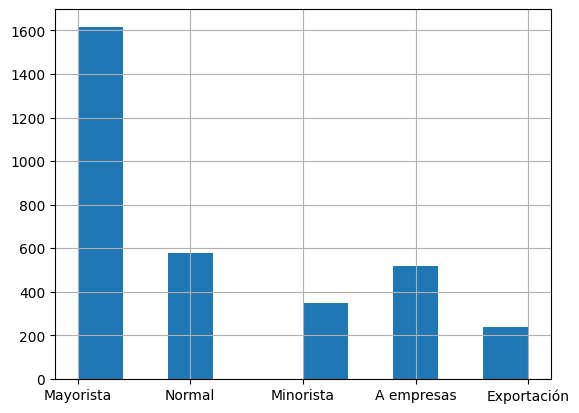

In [116]:
df_ventas['Grupo_Venta'].hist()

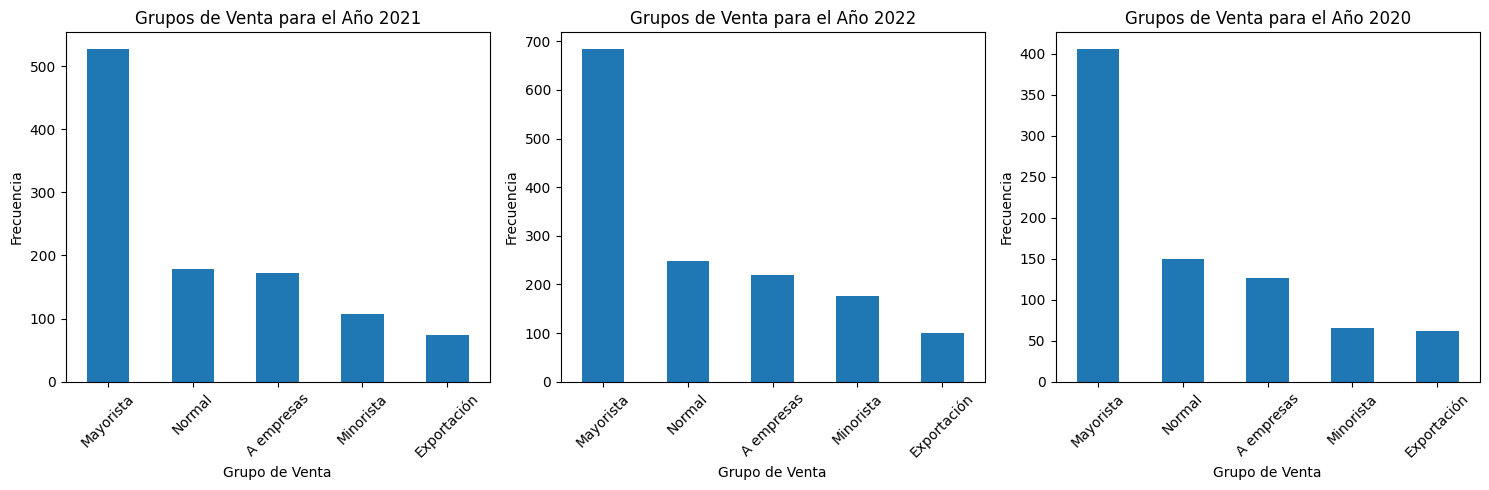

In [117]:
# Obtener los años únicos en el DataFrame
años_unicos = df_ventas['Año'].unique()

# Determinar el número de columnas para los subgráficos
num_años = len(años_unicos)
num_columnas = 3  # Ajusta según cuántos gráficos quieras por fila
num_filas = 1

# Crear subgráficos
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(15, 5 * num_filas))

# Aplanar el array de ejes para facilitar el acceso
axes = axes.flatten()

# Crear un histograma para cada año
for i, año in enumerate(años_unicos):
    # Filtrar los datos del año actual
    df_año = df_ventas[df_ventas['Año'] == año]
    
    # Crear el histograma para la columna 'Grupo_Venta'
    df_año['Grupo_Venta'].value_counts().plot(kind='bar', ax=axes[i])
    
    # Configuración del gráfico
    axes[i].set_title(f'Grupos de Venta para el Año {año}')
    axes[i].set_xlabel('Grupo de Venta')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

# Ajustar el layout para que los gráficos no se sobrepongan
plt.tight_layout()

# Mostrar los gráficos
plt.show()

<Axes: ylabel='Cantidad'>

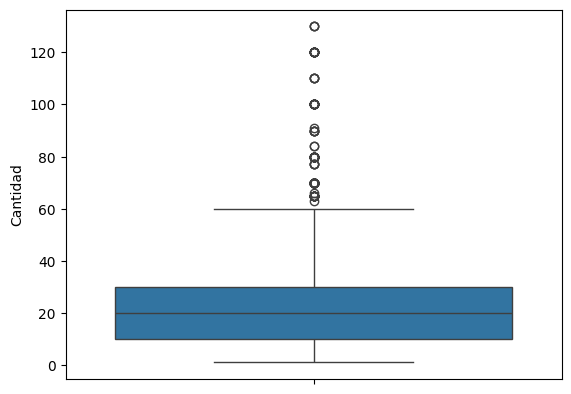

In [118]:
sns.boxplot(data=df_ventas['Cantidad'])

In [146]:
#Cantidad de tickets por año
df_ventas['Año'].value_counts()

Año
2022    1428
2021    1059
2020     810
Name: count, dtype: int64

## Resumen datos categoricos

In [119]:
df_ventas['CategoryName'].value_counts()

CategoryName
Bebidas              605
Productos Lácteos    582
Mariscos             508
Dulces               503
Condimentos          326
Granos/Cereales      297
Carnes/Aves          270
Productos Frescos    206
Name: count, dtype: int64

In [120]:
df_ventas['Grupo_Venta'].value_counts()

Grupo_Venta
Mayorista      1617
Normal          577
A empresas      517
Minorista       350
Exportación     236
Name: count, dtype: int64

In [121]:
df_ventas['Country'].value_counts()

Country
USA            550
Germany        522
Brazil         312
France         275
UK             210
Austria        193
Venezuela      169
Sweden         148
Mexico         114
Canada         108
Ireland         93
Finland         87
Switzerland     82
Spain           79
Italy           78
Denmark         76
Belgium         71
Portugal        46
Argentina       39
Poland          24
Norway          21
Name: count, dtype: int64

In [132]:
df_ventas['Country'].nunique()

21

In [133]:
df_ventas['Region'].value_counts()

Region
Europe           2005
North America     772
South America     520
Name: count, dtype: int64

# RESUMEN ANALISIS PREVIO

Se detemino que la empresa tiene mayor volumen de ventas va dirigido a venta mayorista (11-30 productos). El valor más repetido es 20 y las ventas por arriba de 60 unidades se consideran poco frecuentes.

El top 5 de los paises con mayor N° de pedidos son USA,GER,BR,FR y Uk. Si mercado objetivo es el europeo.

Los productos más vendidos son Bebidas, Lácteos, Marisco y Dulces.

# OBJETIVOS DE PROYECTO

1. Un gráfico de beneficios y ingresos.
2. Se desea determinar los paises que generaron el mayor ingreso para la empresa el ultimo año.
3. La distribución de ingreso del último por tipo de producto.
4. La distribución de ingreso del último por grupo de venta.
5. El crecimiento de ventas por región del ultimo año y del top 5 paises.


### Objetivo 1

In [125]:
df_agrupado = df_ventas.groupby(['Año', 'Mes']).agg({
    'PTotal': 'sum',
    'Utilidad': 'sum'
}).reset_index()

tablas_por_año = {year: df_agrupado[df_agrupado['Año'] == year] for year in df_agrupado['Año'].unique()}
print(df_agrupado)

     Año  Mes  PTotal  Utilidad
0   2020    1   45238   22422.7
1   2020    2   26097   13307.5
2   2020    3   25484   12914.8
3   2020    4   28152   14363.9
4   2020    5   37517   18799.3
5   2020    6   45600   23685.6
6   2020    7   27864   13975.7
7   2020    8   25484   13033.8
8   2020    9   26385   13400.8
9   2020   10   37517   18977.9
10  2020   11   45600   23245.5
11  2020   12   45238   22479.6
12  2021    1   61257   31155.8
13  2021    2   38486   18910.7
14  2021    3   38547   19636.1
15  2021    4   53038   27670.4
16  2021    5   53786   26371.7
17  2021    6   36365   18281.5
18  2021    7   51023   25473.1
19  2021    8   47295   23426.2
20  2021    9   55633   27425.7
21  2021   10   66753   32982.9
22  2021   11   43536   21790.3
23  2021   12   71406   36284.6
24  2022    1   94231   46678.3
25  2022    2   99424   46398.4
26  2022    3  104865   52291.0
27  2022    4  123805   62791.2
28  2022    5  103581   51950.4
29  2022    6   58640   29178.9
30  2022

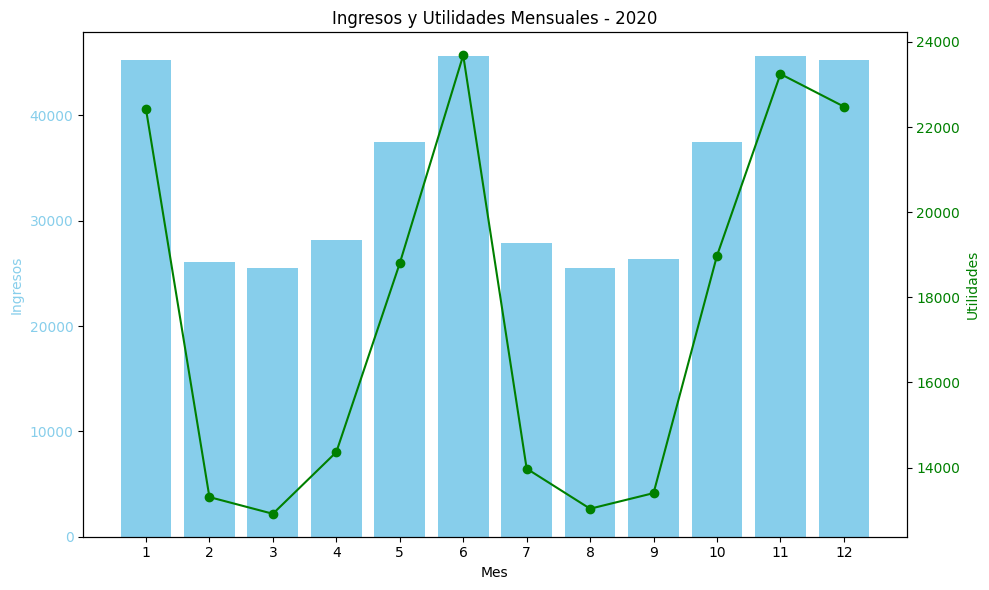

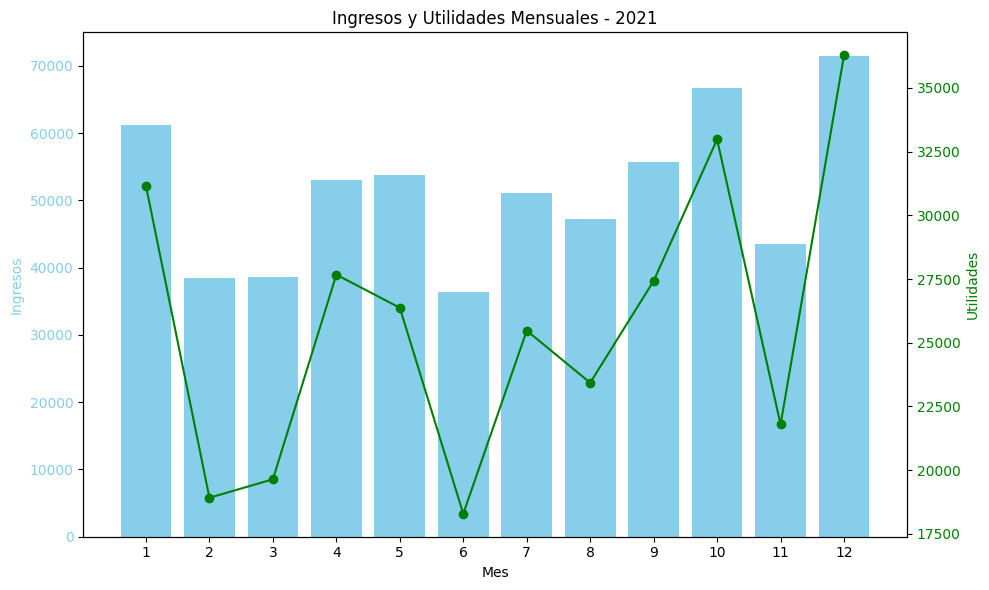

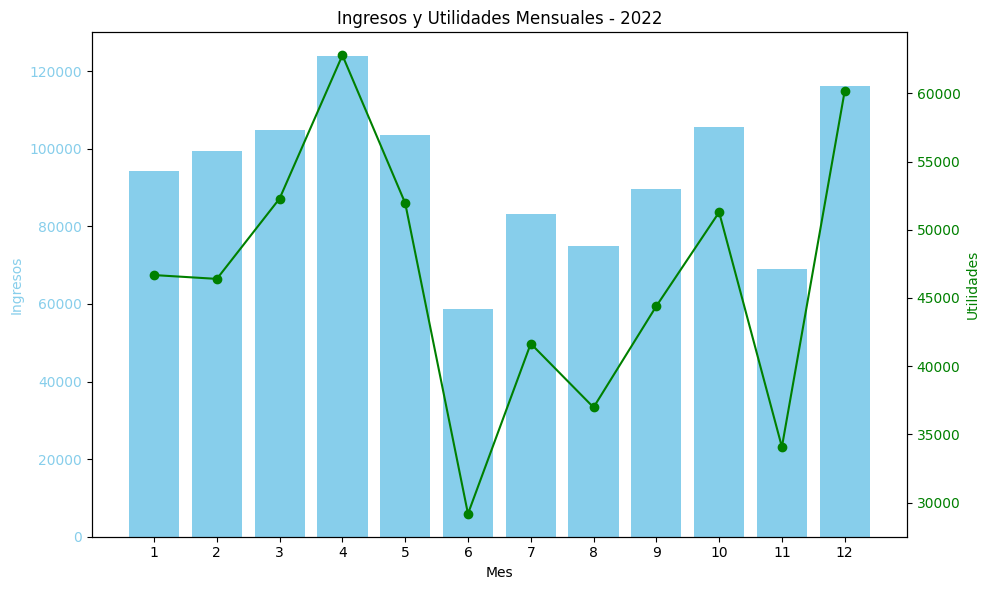

In [126]:
#Ciclo For
for year in df_agrupado['Año'].unique():
    df_year = df_agrupado[df_agrupado['Año'] == year]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Gráfico de Barra
    ax1.bar(df_year['Mes'], df_year['PTotal'], color='skyblue', label='Ingresos')
    ax1.set_xlabel('Mes')
    ax1.set_ylabel('Ingresos', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')
    ax1.set_xticks(df_year['Mes'])
    
    # Crear un segundo eje para las utilidades mensuales
    ax2 = ax1.twinx()
    ax2.plot(df_year['Mes'], df_year['Utilidad'], color='green', marker='o', label='Utilidades')
    ax2.set_ylabel('Utilidades', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Agregar un título y mostrar el gráfico
    plt.title(f'Ingresos y Utilidades Mensuales - {year}')
    fig.tight_layout()
    plt.show()

### Objetivo 2

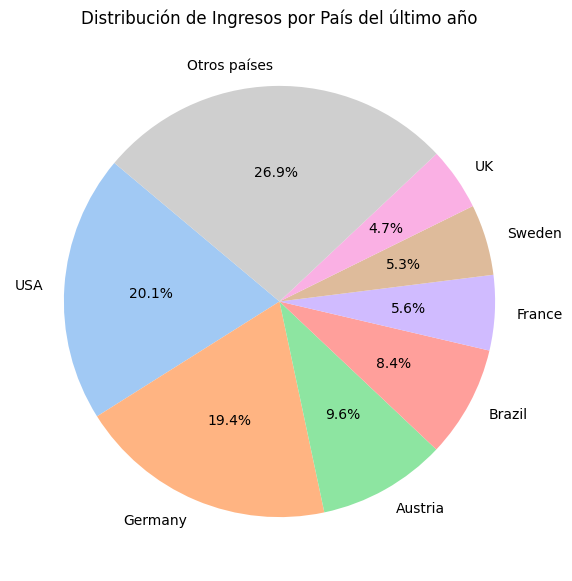

        Country  PTotal
0           USA  225172
1       Germany  217788
2       Austria  108108
3        Brazil   94124
4        France   63285
5        Sweden   59736
6            UK   52904
7  Otros países  301828


In [127]:
last_year = df_ventas['Año'].max()
df_last_year = df_ventas[df_ventas['Año'] == last_year ]

# Agrupar por país y sumar los ingresos
ingresos_por_pais = df_last_year.groupby('Country')['PTotal'].sum().reset_index()

# Ordenar por ingresos en orden descendente
ingresos_por_pais = ingresos_por_pais.sort_values(by='PTotal', ascending=False)

# Seleccionar el top 7 países y Otros
top_7_paises = ingresos_por_pais.head(7)
otros_paises = ingresos_por_pais.tail(-7).sum()
otros_paises = pd.DataFrame([otros_paises], columns=ingresos_por_pais.columns)
otros_paises['Country'] = 'Otros países'

df_top7_otros = pd.concat([top_7_paises, otros_paises], ignore_index=True)

plt.figure(figsize=(10, 7))
plt.pie(df_top7_otros['PTotal'], labels=df_top7_otros['Country'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Distribución de Ingresos por País del último año')
plt.show()

print (df_top7_otros )

In [135]:
#TOP 5 paises con menores ventas
ingresos_por_pais.tail(5)

,Country,PTotal
10,Italy,15484
14,Portugal,8105
0,Argentina,7547
12,Norway,4726
13,Poland,3679


Objetivo 3: Distribución de ingreso del último por tipo de producto.

In [176]:
#Usar el data Frame que contiene los datos del último año "df_last_year"

df_categ_LY = df_last_year.groupby('CategoryName')['PTotal'].sum().reset_index().sort_values(by='PTotal', ascending=False)

df_categ_LY

,CategoryName,PTotal
7,Productos Lácteos,216063
0,Bebidas,213097
1,Carnes/Aves,145168
3,Dulces,137819
5,Mariscos,133229
6,Productos Frescos,94627
2,Condimentos,92118
4,Granos/Cereales,90824


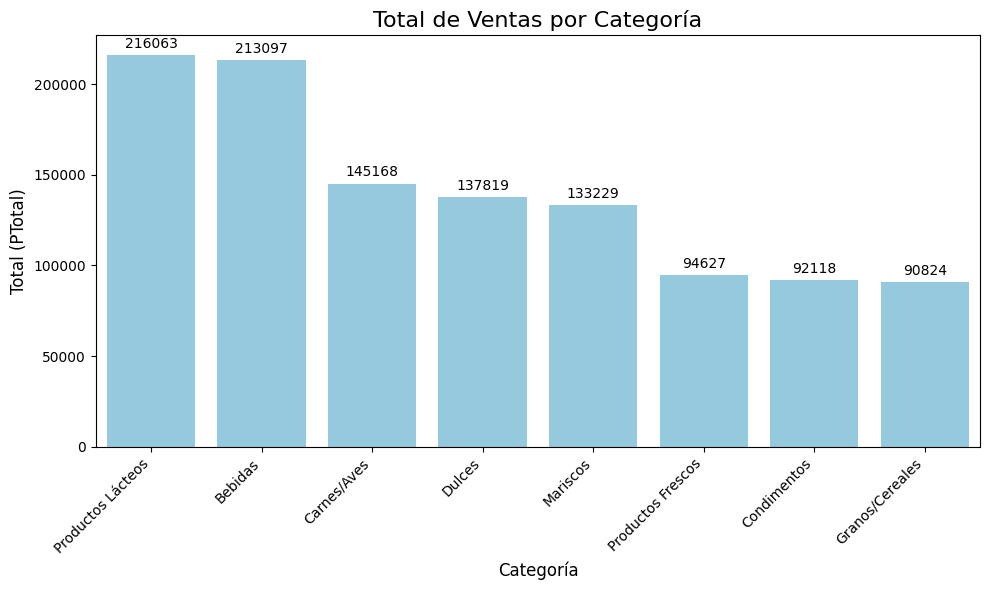

In [195]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='CategoryName',
    y='PTotal',
    data=df_categ_LY,
    color='skyblue'
)

# Agregar etiquetas de datos a cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=10, padding=3)

# Personalizar el gráfico
plt.title('Total de Ventas por Categoría', fontsize=16)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Total (PTotal)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Objetivo 3: Distribución de ingreso del último por grupo de venta

In [190]:
df_g_Venta = df_last_year.groupby('Grupo_Venta')['PTotal'].sum().reset_index().sort_values(by='PTotal', ascending=False)

df_g_Venta['Porcentaje'] = (df_g_Venta['PTotal'] / df_g_Venta['PTotal'].sum()) * 100
df_g_Venta

,Grupo_Venta,PTotal,Porcentaje
2,Mayorista,488101,43.466154
0,A empresas,289689,25.797256
1,Exportación,247954,22.080690
4,Normal,75318,6.707185
3,Minorista,21883,1.948715


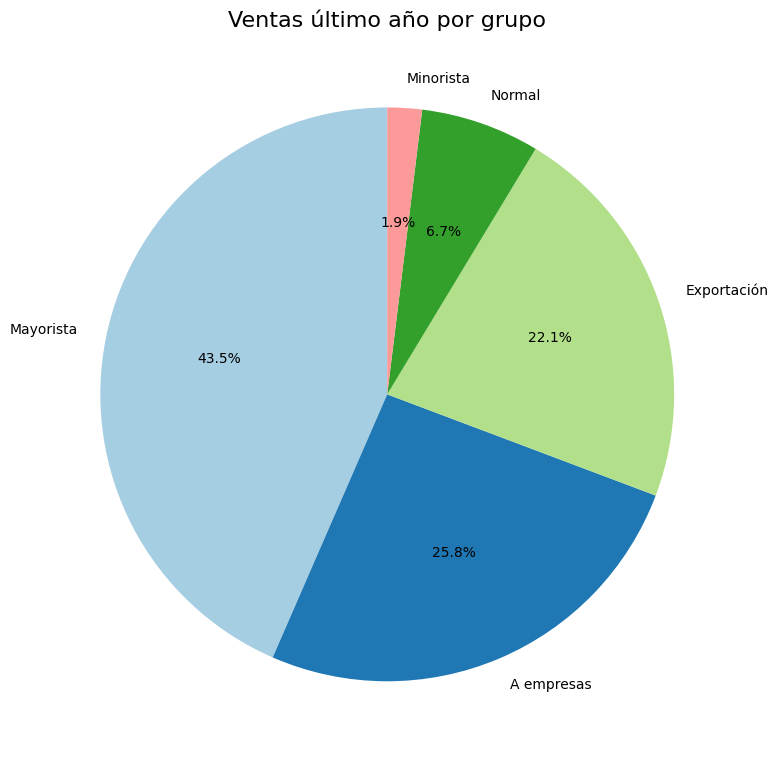

In [192]:
# Crear el gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(
    df_g_Venta['PTotal'],
    labels=df_g_Venta['Grupo_Venta'],
    autopct='%1.1f%%',  # Mostrar porcentaje con un decimal
    startangle=90,      # Iniciar el gráfico desde el ángulo de 90 grados
    colors=plt.cm.Paired.colors  # Usar una paleta de colores predefinida
)

# Título
plt.title('Ventas último año por grupo', fontsize=16)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

OBJETIVO 5: El crecimiento de ventas por región del ultimo año y del top 5 paises.

In [201]:
df_2021 = df_ventas[df_ventas['Año'] == 2021].groupby('Country').agg({'PTotal': 'sum', 'Utilidad': 'sum'}).reset_index()
df_2022 = df_ventas[df_ventas['Año'] == 2022].groupby('Country').agg({'PTotal': 'sum', 'Utilidad': 'sum'}).reset_index()


df_2021.rename(columns={'PTotal': 'Ventas_2021', 'Utilidad': 'Utilidad_2021'}, inplace=True)
df_2022.rename(columns={'PTotal': 'Ventas_2022', 'Utilidad': 'Utilidad_2022'}, inplace=True)

comparacion = pd.merge(df_2021, df_2022, on='Country', how='outer').fillna(0)

In [223]:
#Variaciones

comparacion['% Variación Ventas'] = round(
    ((comparacion['Ventas_2022'] - comparacion['Ventas_2021']) / comparacion['Ventas_2021'].replace(0, float('nan'))) * 100, 1
)
comparacion['% Variación Utilidad'] = round(
    ((comparacion['Utilidad_2022'] - comparacion['Utilidad_2021']) / comparacion['Utilidad_2021'].replace(0, float('nan'))) * 100, 1
)
comparacion = comparacion.sort_values(by='Utilidad_2022',ascending=False)


In [224]:
comparacion

,Country,Ventas_2021,Utilidad_2021,Ventas_2022,Utilidad_2022,% Variación Ventas,% Variación Utilidad
19,USA,114851,57955.6,225172,111043.1,96.1,91.6
8,Germany,117332,58879.8,217788,108194.6,85.6,83.8
1,Austria,57401,29143.1,108108,53629.0,88.3,84.0
3,Brazil,41945,20739.6,94124,46768.3,124.4,125.5
7,France,45265,22786.2,63285,31120.2,39.8,36.6
16,Sweden,27167,12628.6,59736,29472.1,119.9,133.4
18,UK,27076,13336.4,52904,27569.8,95.4,106.7
20,Venezuela,26407,13334.8,46707,23588.5,76.9,76.9
9,Ireland,20457,10288.5,46726,22619.5,128.4,119.9
4,Canada,31298,16030.4,36344,17621.6,16.1,9.9


In [255]:
TCambio

,Moneda,Precio
0,Dólar Libre,"1050,00"
1,Dólar Mayorista,"1032,93"
2,Dólar MEP/Bolsa,"1049,90"
3,Contado con liqui,"1072,50"
4,Euro,"1029,77"
5,Real brasileño,"171,17"
6,Peso uruguayo,"23,18"
7,Peso chileno,"100,71"


In [272]:
eliminar=["Ventas_2021","Utilidad_2021"]
df_Resultado= comparacion.drop (columns=eliminar)

In [273]:
df_Resultado

,Country,Ventas_2022,Utilidad_2022,% Variación Ventas,% Variación Utilidad
19,USA,225172,111043.1,96.1,91.6
8,Germany,217788,108194.6,85.6,83.8
1,Austria,108108,53629.0,88.3,84.0
3,Brazil,94124,46768.3,124.4,125.5
7,France,63285,31120.2,39.8,36.6
16,Sweden,59736,29472.1,119.9,133.4
18,UK,52904,27569.8,95.4,106.7
20,Venezuela,46707,23588.5,76.9,76.9
9,Ireland,46726,22619.5,128.4,119.9
4,Canada,36344,17621.6,16.1,9.9


In [275]:
print("La empresa accepta las siguientes monedas:")
print(TCambio)

# Solicitar al usuario que ingrese el índice
indice = int(input("Ingrese el índice de la moneda que desea seleccionar: "))

# Obtener el valor de la columna "Moneda" en el índice proporcionado
moneda_seleccionada = TCambio.loc[indice, "Moneda"]


print(f"La moneda seleccionada es: {moneda_seleccionada}")

if indice in [0, 1, 2, 3, 4]:  # Para índices 0-4, tomar el precio directamente
    precio_seleccionado = TCambio.loc[indice, "Precio"]
else:  # Para índices 5, 6, 7, hacer la operación de división
    precio_dolar_mep = TCambio.loc[2, "Precio"]  # Tomamos el valor del Dólar MEP/Bolsa (índice 2)
    precio_seleccionado = precio_dolar_mep / TCambio.loc[indice, "Precio"]

# Agregar la columna "TCpesos" al DataFrame df_Resultado con el valor seleccionado
df_Resultado["TCpesos"] = precio_seleccionado

df_Resultado["PrecioFinal en millones de $"]=round( precio_seleccionado*df_Resultado["Ventas_2022"]/1000000,2)



df_Resultado

La empresa accepta las siguientes monedas:
              Moneda   Precio
0        Dólar Libre  1050.00
1    Dólar Mayorista  1032.93
2    Dólar MEP/Bolsa  1049.90
3  Contado con liqui  1072.50
4               Euro  1029.77
5     Real brasileño   171.17
6      Peso uruguayo    23.18
7       Peso chileno   100.71


Ingrese el índice de la moneda que desea seleccionar:  4


La moneda seleccionada es: Euro


,Country,Ventas_2022,Utilidad_2022,% Variación Ventas,% Variación Utilidad,TCpesos,PrecioFinal en millones de $
19,USA,225172,111043.1,96.1,91.6,1029.77,231.88
8,Germany,217788,108194.6,85.6,83.8,1029.77,224.27
1,Austria,108108,53629.0,88.3,84.0,1029.77,111.33
3,Brazil,94124,46768.3,124.4,125.5,1029.77,96.93
7,France,63285,31120.2,39.8,36.6,1029.77,65.17
16,Sweden,59736,29472.1,119.9,133.4,1029.77,61.51
18,UK,52904,27569.8,95.4,106.7,1029.77,54.48
20,Venezuela,46707,23588.5,76.9,76.9,1029.77,48.10
9,Ireland,46726,22619.5,128.4,119.9,1029.77,48.12
4,Canada,36344,17621.6,16.1,9.9,1029.77,37.43


### DATOS PARA COMPETIR

Al ver la posible rentabilidad una empresa ARG quiere analizar que posible ganancia se obtendria de captar parte del mercado. Se solicitar analizar los rubros donde las empresas nacionales se destacan.

In [280]:
Rubros_a_competir=["Granos/Cereales","Productos Lácteos","Carnes/Aves"]
Mercado2022=df_last_year[df_last_year['CategoryName'].isin(Rubros_a_competir)]

In [281]:
Mercado2022

,PTotal,Costo,Region,Country,CategoryName,Mes,Año,Cantidad,P.Unit,Utilidad,Grupo_Venta
3,825,486.8,Europe,Germany,Productos Lácteos,1,2022,15,55.00,338.2,Mayorista
5,430,236.5,Europe,Germany,Productos Lácteos,4,2022,20,21.50,193.5,Mayorista
18,714,321.3,Europe,Germany,Productos Lácteos,4,2022,21,34.00,392.7,Mayorista
36,656,269.0,Europe,Germany,Carnes/Aves,1,2022,20,32.80,387.0,Mayorista
38,1650,940.5,Europe,Germany,Productos Lácteos,4,2022,30,55.00,709.5,Mayorista
...,...,...,...,...,...,...,...,...,...,...,...
3281,1530,810.9,North America,USA,Productos Lácteos,9,2022,30,34.00,719.1,Mayorista
3284,5904,2893.0,North America,USA,Carnes/Aves,10,2022,120,32.80,3011.0,Exportación
3288,1114,501.3,North America,USA,Carnes/Aves,8,2022,6,123.79,612.7,Normal
3290,53,23.6,North America,USA,Productos Lácteos,6,2022,14,2.50,29.4,Mayorista


In [295]:
df_2022_mercado = Mercado2022[Mercado2022['Año'] == 2022].groupby(['Country', 'CategoryName']).agg({'PTotal': 'sum'}).reset_index()

df_2022_mercado.rename(columns={'PTotal': 'Ventas_2022'}, inplace=True)
df_2022_mercado = df_2022_mercado.sort_values(by='Ventas_2022', ascending=False)

In [296]:
df_2022_mercado.head(15)

,Country,CategoryName,Ventas_2022
25,Germany,Productos Lácteos,42531
54,USA,Productos Lácteos,37115
52,USA,Carnes/Aves,32290
4,Austria,Productos Lácteos,27598
26,Ireland,Carnes/Aves,24754
53,USA,Granos/Cereales,20846
23,Germany,Carnes/Aves,20570
57,Venezuela,Productos Lácteos,16128
51,UK,Productos Lácteos,12218
2,Austria,Carnes/Aves,12096


In [ ]:
Se desea captar el 5% del mercado

In [319]:
df_Arg = df_2022_mercado.copy()
df_Arg['Ventas_2022'] = df_Arg['Ventas_2022'] * 0.05

df_Arg.rename(columns={'Ventas_2022': 'Ventas_Arg'}, inplace=True)

df_Arg.head(10)

,Country,CategoryName,Ventas_Arg
25,Germany,Productos Lácteos,2126.55
54,USA,Productos Lácteos,1855.75
52,USA,Carnes/Aves,1614.50
4,Austria,Productos Lácteos,1379.90
26,Ireland,Carnes/Aves,1237.70
53,USA,Granos/Cereales,1042.30
23,Germany,Carnes/Aves,1028.50
57,Venezuela,Productos Lácteos,806.40
51,UK,Productos Lácteos,610.90
2,Austria,Carnes/Aves,604.80


In [320]:
##.groupby(['Country', 'CategoryName']).agg({'PTotal': 'sum'}).reset_index()

df_Arg_category=df_Arg.groupby(['CategoryName']).agg({'Ventas_Arg': 'sum'}).reset_index()

In [321]:
df_Arg_category

,CategoryName,Ventas_Arg
0,Carnes/Aves,7258.40
1,Granos/Cereales,4541.20
2,Productos Lácteos,10803.15
